In [6]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [5]:
from sklearn.datasets import load_iris
iris = load_iris()
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [8]:
pip install numpy matplotlib

  Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 15.3 MB/s  0:00:00
Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl (7.2 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ----------------

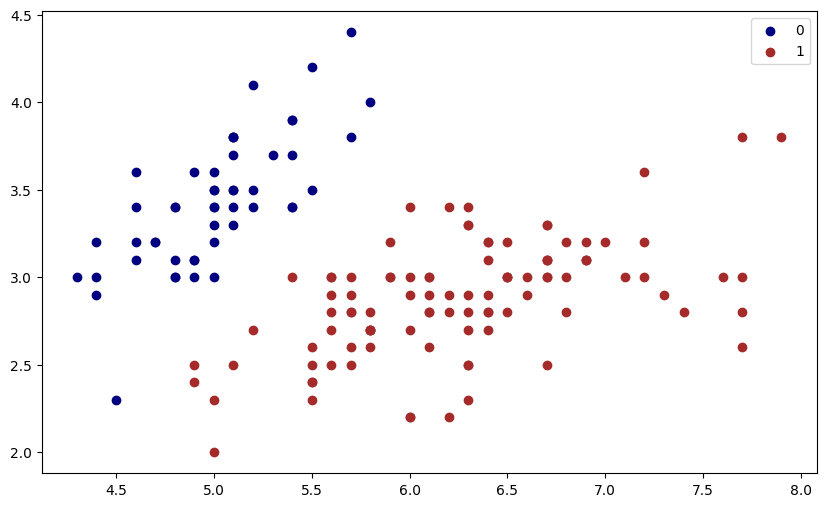

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

# 데이터 플롯도를 작성
iris = datasets.load_iris()

# iris.data는 꽃받침의 길이, 꽃받침의 폭, 꽃잎의 길이, 꽃잎의 폭에 대해서의 데이터가 저장되어 있는
# ndarray의 이차원 배열
X = iris.data[:, :2]

# iris.target은 0(=setosa), 1(=versicolor), 2(=virginica)이 저장되어 있는 ndarray의
# 일차원 배열
y = np.where(iris.target!=0, 1, iris.target)

plt.figure(figsize=(10, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='navy', label='0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='brown', label='1')
plt.legend();

In [14]:
import numpy as np
from sklearn.datasets import load_iris

# 1. 필요한 함수들 정의
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def cross_entropy(h, y):
    # 로그 계산 시 0이 들어가는 것을 방지하기 위해 아주 작은 값(1e-15)을 더해줍니다.
    return (-y * np.log(h + 1e-15) - (1 - y) * np.log(1 - h + 1e-15)).mean()

def add_intercept(X):
    # 데이터에 편향(bias)을 위한 1을 추가합니다.
    intercept = np.ones((X.shape[0], 1))
    return np.concatenate((intercept, X), axis=1)

def predict_prob(X, theta):
    X_intercept = add_intercept(X)
    return sigmoid(np.dot(X_intercept, theta))

def predict(X, theta, threshold=0.5):
    return predict_prob(X, theta) >= threshold

# 2. 데이터 준비
iris = load_iris()
X = iris.data[:, :2]
# 붓꽃 데이터 중 0번 타겟만 분류하는 이진 분류로 가정 (기존 코드의 y 설정 유지)
y = (iris.target != 0).astype(int) 

# 3. 하이퍼파라미터 및 초기화
lr = 0.1
iter_nums = 300000
X_intercept = add_intercept(X)
theta = np.zeros(X_intercept.shape[1])

# 4. 학습 (최급 강하법)
print("학습 시작...")
for i in range(iter_nums):
    z = np.dot(X_intercept, theta)
    h = sigmoid(z)
    
    # 기울기 계산
    gradient = np.dot(X_intercept.T, (h - y)) / y.size
    
    # 가중치 갱신
    theta = theta - lr * gradient
    
    # 오차 출력 (10000번마다)
    if i % 10000 == 0:
        loss = cross_entropy(h, y)
        print(f'Iteration {i}: loss = {loss}')

print("학습 완료!\n")

# 5. 결과 확인
final_prob = predict_prob(X, theta)
final_pred = predict(X, theta)

print(f"최종 확률값(일부): {final_prob[:5]}")
print(f"최종 예측 라벨(일부): {final_pred[:5]}")

학습 시작...
Iteration 0: loss = 0.6931471805599433
Iteration 10000: loss = 0.03432808634642234
Iteration 20000: loss = 0.0287870258321324
Iteration 30000: loss = 0.025718807764276073
Iteration 40000: loss = 0.023408635212946064
Iteration 50000: loss = 0.02150719901717591
Iteration 60000: loss = 0.019892517590829578
Iteration 70000: loss = 0.018503295528765912
Iteration 80000: loss = 0.017299305807069166
Iteration 90000: loss = 0.016249836794913458
Iteration 100000: loss = 0.015329924723358743
Iteration 110000: loss = 0.01451890984433493
Iteration 120000: loss = 0.01379967286593781
Iteration 130000: loss = 0.013158067641993287
Iteration 140000: loss = 0.012582429565327909
Iteration 150000: loss = 0.012063141842399462
Iteration 160000: loss = 0.011592261833139753
Iteration 170000: loss = 0.011163207785514759
Iteration 180000: loss = 0.010770501660659348
Iteration 190000: loss = 0.010409560916001592
Iteration 200000: loss = 0.01007653127087165
Iteration 210000: loss = 0.009768152873868874
It

In [15]:
# 오차를 보면서 lr을 조정
# 학습률(learning rate)을 조정하면서 가중치를 갱신하고, 교차 엔트로피 오차가 한없이 0에 가까워질 때의 학습률을 찾는다

lr = 0.1
iter_nums = 300000

X = add_intercept(X)

# 가중치의 초기화
theta = np.zeros(X.shape[1])

# 최급강하법
for i in range(iter_nums):
    z = np.dot(X, theta)
    h = sigmoid(z)
    
    # 기울기(=편미분항)를 계산
    gradient = np.dot(X.T, (h - y)) / y.size
    # 가중치를 갱신
    theta = theta - lr * gradient
    
    # 교차 엔트로피 오차를 저장
    loss = cross_entropy(h, y)
    if (i % 10000 == 0):
        # 교차 엔트로피 오차를 출력
        print(f'loss: {loss} \t')

# 확률값을 예측
iris = load_iris()
X = iris.data[:, :2]
predict_prob(X, theta)

# 확률값을 사용하여 분류 라벨을 예측
predict(X, theta)

loss: 0.6931471805599433 	
loss: 0.03432808634642234 	
loss: 0.0287870258321324 	
loss: 0.025718807764276073 	
loss: 0.023408635212946064 	
loss: 0.02150719901717591 	
loss: 0.019892517590829578 	
loss: 0.018503295528765912 	
loss: 0.017299305807069166 	
loss: 0.016249836794913458 	
loss: 0.015329924723358743 	
loss: 0.01451890984433493 	
loss: 0.01379967286593781 	
loss: 0.013158067641993287 	
loss: 0.012582429565327909 	
loss: 0.012063141842399462 	
loss: 0.011592261833139753 	
loss: 0.011163207785514759 	
loss: 0.010770501660659348 	
loss: 0.010409560916001592 	
loss: 0.01007653127087165 	
loss: 0.009768152873868874 	
loss: 0.009481653254136862 	
loss: 0.009214661554387415 	
loss: 0.008965139601332904 	
loss: 0.008731326283946345 	
loss: 0.008511692462680692 	
loss: 0.00830490423474029 	
loss: 0.008109792854047268 	
loss: 0.007925329973701592 	


array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

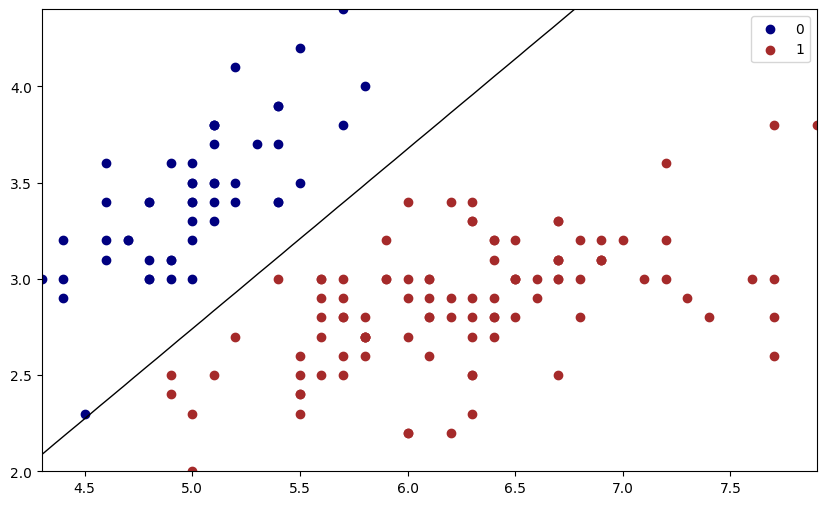

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# 데이터를 플롯
plt.figure(figsize=(10,6))
plt.scatter(X[y ==0][:,0], X[y ==0][:,1], color = 'navy', label='0')
plt.scatter(X[y ==1][:,0], X[y ==1][:,1], color = 'brown', label='1')
plt.legend() # 이 부분만 ()를 붙여주세요.

# x축의 스케일 폭을 정의
x_min, x_max = X[:,0].min(), X[:,0].max()
# y축의 스케일 폭 정의
y_min, y_max = X[:,1].min(), X[:,1].max()
# 세로 축과 가로 축의 표시
xx, yy = np.meshgrid(np.linspace(x_min, x_max), np.linspace(y_min, y_max))
grid = np.c_[xx.ravel(), yy.ravel()]
# 분류한 선을 표시
probs = predict_prob(grid, theta).reshape(xx.shape)
plt.contour(xx,yy,probs, [0.5], linewidths=1, colors='black');